# TP01 — Du SI à une première prédiction

**Introduction au Machine Learning — M2 MIAGE**  
Université Paris Dauphine – PSL

## Mission

Vous travaillez dans l'équipe Data d'une marketplace. Au moment où une commande vient d'être validée et où une date estimée de livraison a été communiquée au client, l'entreprise souhaite mieux anticiper son délai réel de livraison.

**Question métier : peut-on prédire le nombre de jours nécessaires pour livrer une commande ?**

Dans ce TP, l'objectif n'est pas seulement d'entraîner un modèle. Nous allons suivre toute la chaîne de raisonnement :

**SI → unité statistique → table analytique → variables disponibles → baseline → modèle → évaluation → analyse des erreurs.**

### Objectifs

À la fin du TP, vous devrez être capable de :
- traduire une question métier en problème de Machine Learning ;
- identifier la granularité d'un jeu de données ;
- repérer une fuite de données (*data leakage*) ;
- construire une baseline ;
- entraîner une première régression linéaire ;
- interpréter MAE, RMSE et \(R^2\) ;
- analyser les limites d'un modèle au-delà d'un simple score.

## 1. Avant de coder : quel problème cherchons-nous à résoudre ?

Répondez d'abord aux questions suivantes.

**Q1.** S'agit-il d'un problème supervisé ou non supervisé ? Justifiez.

**Q2.** S'agit-il d'une classification ou d'une régression ? Justifiez.

**Q3.** Quelle doit être l'unité statistique de notre jeu d'apprentissage ?

**Q4.** Quelle est la variable que nous souhaitons prédire ?

> Ne poursuivez pas immédiatement : formulez le problème sous la forme $X \rightarrow Y$.

### ✅ Correction

**Q1.** Il s'agit d'un problème **supervisé** : pour chaque commande passée, nous disposons d'une valeur observée du délai réel de livraison. Le modèle apprend donc à partir d'exemples pour lesquels la cible est connue.

**Q2.** Il s'agit d'une **régression**, car la grandeur à prédire est quantitative : un nombre de jours de livraison.

**Q3.** L'unité statistique doit être **la commande**. Une ligne du jeu d'apprentissage doit correspondre à une commande, puisque nous voulons produire une prédiction par commande.

**Q4.** La variable cible $Y$ est `delivery_time_days`, c'est-à-dire le délai réel entre l'achat et la livraison au client.

On peut donc résumer le problème ainsi : les caractéristiques connues d'une commande $X$ sont utilisées pour prédire son délai réel de livraison $Y$.


## 2. Du système d'information à la table d'apprentissage

Les données Olist proviennent d'un système transactionnel : les informations relatives à une commande sont réparties dans plusieurs tables.

Dans un SI, la granularité des tables n'est pas nécessairement celle dont un modèle de Machine Learning a besoin.

Par exemple :
- `orders` décrit les commandes ;
- `order_items` décrit les lignes de commande ;
- `products` décrit les produits ;
- `customers` décrit les clients associés aux commandes.

Une commande contenant plusieurs articles apparaît donc plusieurs fois dans `order_items`.

### Question

Pourquoi ne peut-on pas utiliser directement `order_items` comme jeu d'apprentissage si notre objectif est de prédire **un délai par commande** ?

### ✅ Correction

`order_items` est à la granularité **ligne de commande** et non à la granularité **commande**. Une commande comportant plusieurs articles apparaît donc plusieurs fois.

Si nous utilisions directement cette table, une même commande pourrait être présente plusieurs fois avec le même délai de livraison. Les commandes comportant beaucoup d'articles auraient alors davantage de poids dans l'apprentissage.

Il faut donc ramener les informations des lignes de commande à une seule ligne par `order_id`, par exemple en calculant le nombre d'articles, le prix total ou les frais de transport totaux.


### Une agrégation typique

Pour passer d'une table au niveau « article » à une table au niveau « commande », on peut agréger les lignes partageant le même `order_id`.

```python
order_items.groupby("order_id").agg(
    n_items=("order_item_id", "count"),
    total_price=("price", "sum"),
    total_freight=("freight_value", "sum")
)
```

Cette opération illustre une étape essentielle :

$$
\boxed{\text{SI transactionnel} \neq \text{table analytique d'apprentissage}}
$$

Dans la suite, nous utiliserons une table analytique préparée à partir des différentes tables Olist.

## 3. Chargement de la table analytique `orders_ml`

La table est hébergée dans le dépôt GitHub du cours. Elle peut donc être chargée directement dans Google Colab.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "ndiayemairame/miage-machine-learning/"
    "main/data/orders_ml.csv"
)

date_columns = [
    "order_purchase_timestamp",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

orders_ml = pd.read_csv(DATA_URL, parse_dates=date_columns)

print("Dimensions :", orders_ml.shape)
orders_ml.head()

Dimensions : (96470, 33)


,order_id,customer_id,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,purchase_day_of_week,purchase_hour,...,max_product_volume_cm3,n_categories,freight_ratio,main_product_category,seller_customer_distance_mean,seller_customer_distance_max,same_state_share,payment_type_main,payment_installments_max,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,0,10,...,1976.0,1,0.290764,housewares,18.681737,18.681737,1.0,voucher,1.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,1,20,...,4693.0,1,0.191744,perfumery,861.036556,861.036556,0.0,boleto,1.0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,2,8,...,9576.0,1,0.120200,auto,514.547851,514.547851,0.0,credit_card,3.0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,5,19,...,6000.0,1,0.604444,pet_shop,1821.805173,1821.805173,0.0,credit_card,1.0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,1,21,...,11475.0,1,0.438191,stationery,29.593135,29.593135,1.0,credit_card,1.0,5.0


### Notre table analytique

**Granularité : une ligne représente une commande livrée.**

La table contient **96 470 commandes et 33 variables**. Certaines variables proviennent directement du SI, d'autres ont été construites par agrégation ou transformation.

Avant de modéliser, il faut comprendre ce que signifie chaque colonne.

| Variable | Description |
|---|---|
| `order_id` | Identifiant unique de la commande. |
| `customer_id` | Identifiant du client associé à cette commande dans Olist. |
| `order_purchase_timestamp` | Date et heure auxquelles la commande a été passée. |
| `order_delivered_carrier_date` | Date et heure auxquelles la commande a été remise au transporteur. |
| `order_delivered_customer_date` | Date et heure auxquelles la commande a effectivement été livrée au client. |
| `order_estimated_delivery_date` | Date de livraison estimée annoncée pour la commande. |
| `purchase_year` | Année de la commande. |
| `purchase_month` | Mois de la commande, de 1 à 12. |
| `purchase_day_of_week` | Jour de la semaine : 0 = lundi, ..., 6 = dimanche. |
| `purchase_hour` | Heure à laquelle la commande a été passée, de 0 à 23. |
| `promised_delivery_days` | Nombre de jours entre la commande et la date de livraison estimée. |
| `carrier_time_days` | Nombre de jours entre la commande et sa remise effective au transporteur. |
| `delivery_time_days` | Nombre de jours entre la commande et sa livraison effective. **Cible de ce TP.** |
| `is_late` | 1 si la livraison a eu lieu après le jour estimé, 0 sinon. |
| `customer_state` | État brésilien dans lequel se trouve le client. |
| `n_items` | Nombre de lignes/articles dans la commande. |
| `n_products` | Nombre de produits distincts. |
| `n_sellers` | Nombre de vendeurs distincts impliqués. |
| `total_price` | Prix total des articles hors transport, en réais brésiliens (BRL). |
| `total_freight` | Total des frais de transport, en réais brésiliens (BRL). |
| `mean_product_weight_g` | Poids moyen des articles, en grammes. |
| `max_product_weight_g` | Poids maximal des articles, en grammes. |
| `mean_product_volume_cm3` | Volume moyen des articles, en cm³. |
| `max_product_volume_cm3` | Volume maximal des articles, en cm³. |
| `n_categories` | Nombre de catégories de produits distinctes. |
| `main_product_category` | Catégorie la plus représentée dans la commande. |
| `freight_ratio` | Rapport `total_freight / total_price`. |
| `seller_customer_distance_mean` | Distance moyenne entre le client et les vendeurs, en km. |
| `seller_customer_distance_max` | Distance maximale entre le client et les vendeurs, en km. |
| `same_state_share` | Proportion de vendeurs situés dans le même État que le client. |
| `payment_type_main` | Mode de paiement représentant le montant payé le plus important. |
| `payment_installments_max` | Nombre maximal de mensualités associé aux paiements. |
| `review_score` | Note donnée par le client après la commande, généralement de 1 à 5. |

Vérifions la granularité et le schéma

In [ ]:
print("Nombre de lignes :", len(orders_ml))
print("Nombre de colonnes :", orders_ml.shape[1])
print("order_id unique :", orders_ml["order_id"].is_unique)

orders_ml.info()

Nombre de lignes : 96470
Nombre de colonnes : 33
order_id unique : True
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96470 entries, 0 to 96469
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96470 non-null  object        
 1   customer_id                    96470 non-null  object        
 2   order_purchase_timestamp       96470 non-null  datetime64[ns]
 3   order_delivered_carrier_date   96469 non-null  datetime64[ns]
 4   order_delivered_customer_date  96470 non-null  datetime64[ns]
 5   order_estimated_delivery_date  96470 non-null  datetime64[ns]
 6   purchase_year                  96470 non-null  int64         
 7   purchase_month                 96470 non-null  int64         
 8   purchase_day_of_week           96470 non-null  int64         
 9   purchase_hour                  96470 non-null  int64         
 10  promised_d

## 4. Le temps de la prédiction : avons-nous le droit d'utiliser cette information ?

Notre modèle doit produire sa prédiction **juste après validation de la commande, une fois la date estimée de livraison communiquée au client**.

C'est ce moment précis qui détermine les informations disponibles.

Pour chaque variable ci-dessous, classez-la dans l'une des catégories :

- **A** — disponible au moment de la prédiction ;
- **B** — information provenant du futur ;
- **C** — cible ou information directement dérivée du résultat que l'on cherche à prédire.

Justifiez les cas qui vous semblent ambigus.

In [ ]:
variables_to_analyse = [
    "purchase_hour",
    "customer_state",
    "n_items",
    "total_price",
    "total_freight",
    "promised_delivery_days",
    "seller_customer_distance_mean",
    "payment_type_main",
    "order_delivered_carrier_date",
    "carrier_time_days",
    "order_delivered_customer_date",
    "review_score",
    "delivery_time_days",
]

pd.DataFrame({
    "variable": variables_to_analyse,
    "catégorie (A/B/C)": "",
    "justification": ""
})

,variable,catégorie (A/B/C),justification
0,purchase_hour,,
1,customer_state,,
2,n_items,,
3,total_price,,
4,total_freight,,
5,promised_delivery_days,,
6,seller_customer_distance_mean,,
7,payment_type_main,,
8,order_delivered_carrier_date,,
9,carrier_time_days,,


### ✅ Correction — disponibilité des variables

| Variable | Catégorie | Justification |
|---|---|---|
| `purchase_hour` | A | Connue dès l'achat. |
| `customer_state` | A | Information client connue au moment de la commande. |
| `n_items` | A | Le contenu de la commande est connu après validation. |
| `total_price` | A | Montant des articles connu à la validation. |
| `total_freight` | A | Frais de transport connus à la validation. |
| `promised_delivery_days` | A | La date estimée a déjà été communiquée au client dans notre scénario. |
| `seller_customer_distance_mean` | A | Peut être calculée à partir des vendeurs et de l'adresse du client connus à la commande. |
| `payment_type_main` | A | Le moyen de paiement est connu lors de la validation. |
| `order_delivered_carrier_date` | B | La remise effective au transporteur a lieu après la validation. |
| `carrier_time_days` | B | Dépend de la date réelle de remise au transporteur : information future. |
| `order_delivered_customer_date` | C | La date réelle de livraison permet directement de calculer la cible. |
| `review_score` | B | L'avis est donné après la commande et généralement après la livraison. |
| `delivery_time_days` | C | Il s'agit de la variable cible elle-même. |

Le point essentiel est que la légitimité d'une variable dépend du **moment auquel la prédiction doit être produite**. Dans notre scénario, `promised_delivery_days` est utilisable précisément parce que la date estimée a déjà été communiquée au client.


### Proposition d'un collègue

Un collègue vous dit :

> « `carrier_time_days` est très corrélée au délai de livraison. Je propose de l'utiliser dans notre modèle. »

**Q5.** Que pensez-vous de cette proposition ? L'utiliseriez-vous ? Justifiez votre décision à partir du moment auquel notre prédiction doit être produite.

### ✅ Correction

Je n'utiliserais pas `carrier_time_days` dans le modèle correspondant à notre scénario métier.

Notre prédiction doit être produite juste après la validation de la commande. Or `carrier_time_days` mesure le temps écoulé entre l'achat et la remise effective de la commande au transporteur. Cette information n'est donc connue que **plus tard**.

Elle peut être très corrélée au délai final et améliorer fortement les scores tout en étant inutilisable au moment où la prédiction doit réellement être produite. Il s'agit d'une **fuite de données (*data leakage*)**.


## 5. Comprendre la variable cible

La variable cible $Y$ correspond à `delivery_time_days`.

Avant de construire un modèle, explorons sa distribution.

In [ ]:
target = "delivery_time_days"

orders_ml[target].describe()

,delivery_time_days
count,96470.000000
mean,12.558217
std,9.546156
min,0.533414
25%,6.766204
50%,10.217477
75%,15.720182
max,209.628611


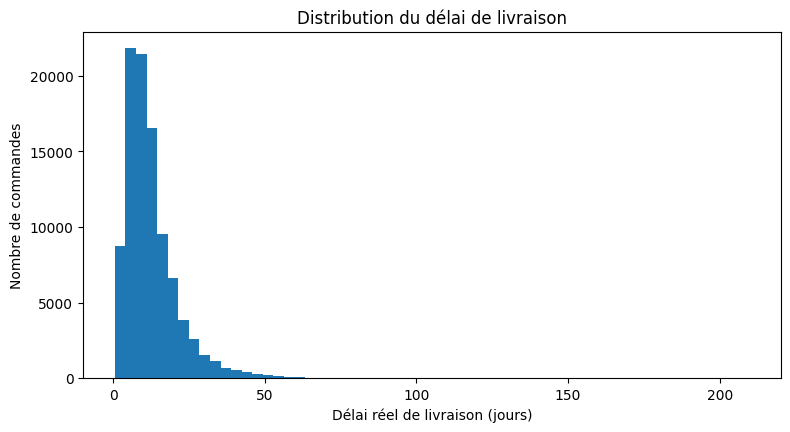

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(orders_ml[target], bins=60)
ax.set_xlabel("Délai réel de livraison (jours)")
ax.set_ylabel("Nombre de commandes")
ax.set_title("Distribution du délai de livraison")
plt.show()

**Q6.** Que représentent concrètement la moyenne, la médiane et les quantiles de cette variable ?

**Q7.** Observez la distribution. Est-elle symétrique ? Quelles conséquences cela peut-il avoir sur les mesures d'erreur ?

### ✅ Correction

**Q6.** La moyenne représente le délai moyen de livraison sur l'ensemble des commandes : environ **12,56 jours**. La médiane, environ **10,22 jours**, signifie que la moitié des commandes sont livrées en moins de 10,22 jours et l'autre moitié en davantage. Les quantiles décrivent la position de la distribution : par exemple, 25 % des commandes sont livrées en moins d'environ **6,77 jours** et 75 % en moins d'environ **15,72 jours**.

**Q7.** La distribution n'est pas symétrique : elle présente une **longue queue vers les délais élevés**. Quelques commandes ont des délais exceptionnellement longs, jusqu'à plus de 200 jours. Ces valeurs extrêmes auront notamment davantage d'influence sur une mesure quadratique comme la RMSE que sur la MAE.


## 6. Séparer apprentissage, validation et test

Nous voulons mesurer la capacité du modèle à généraliser à des commandes qu'il n'a pas utilisées pour apprendre.

Nous allons conserver :
- 70 % des observations pour l'apprentissage ;
- 15 % pour la validation et les choix expérimentaux ;
- 15 % pour le test final.

Le jeu de test restera de côté jusqu'à la fin.

In [ ]:
from sklearn.model_selection import train_test_split

train, temp = train_test_split(
    orders_ml,
    test_size=0.30,
    random_state=42
)

validation, test = train_test_split(
    temp,
    test_size=0.50,
    random_state=42
)

print(f"Train      : {len(train):,}")
print(f"Validation : {len(validation):,}")
print(f"Test       : {len(test):,}")

Train      : 67,529
Validation : 14,470
Test       : 14,471


### Question

Pourquoi serait-il problématique de regarder continuellement les performances sur le jeu de test pendant que nous choisissons nos variables et nos modèles ?

### ✅ Correction

Si nous regardons continuellement les performances sur le jeu de test pour choisir les variables, les modèles ou les réglages, nous finissons indirectement par adapter nos décisions à ce jeu de test.

Le test ne représenterait alors plus une évaluation réellement indépendante. Le jeu de **validation** sert aux choix expérimentaux ; le jeu de **test** doit rester de côté jusqu'à l'évaluation finale.


## 7. Avant le Machine Learning : construire une baseline

Un modèle n'est intéressant que s'il fait mieux qu'une stratégie simple.

Imaginons un système naïf qui prédit **le même délai pour toutes les commandes**.

Nous utiliserons comme prédiction la moyenne du délai observé sur le jeu d'apprentissage.

**Q8.** Pourquoi cette moyenne doit-elle être calculée uniquement sur `train` ?

### ✅ Correction

**Q8.** La moyenne utilisée par la baseline doit être calculée uniquement sur `train`, car elle constitue déjà une information apprise à partir des données. La calculer avec `validation` ou `test` ferait intervenir des observations qui sont censées rester inconnues au moment de l'apprentissage.

Ici, la baseline prédit environ **12,56 jours** pour toutes les commandes.


In [ ]:
baseline_value = train[target].mean()
y_val = validation[target]

y_pred_baseline = np.full(len(validation), baseline_value)

print(f"Prédiction constante : {baseline_value:.2f} jours")

Prédiction constante : 12.56 jours


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

baseline_metrics = regression_metrics(y_val, y_pred_baseline)
pd.Series(baseline_metrics)

,0
MAE,6.449854
RMSE,9.380342
R2,-0.000018


### Interprétation

**Q9.** Traduisez la MAE en une phrase compréhensible par un responsable métier.

**Q10.** Pourquoi le \(R^2\) de cette baseline est-il proche de 0 ?

**Q11.** Pourquoi la RMSE est-elle généralement supérieure à la MAE ?

### ✅ Correction

**Q9.** La MAE de la baseline vaut environ **6,45 jours**. On peut donc dire : « en moyenne, la prédiction constante de notre baseline se trompe d'environ 6,45 jours sur le délai réel de livraison ».

**Q10.** Le $R^2$ est pratiquement nul car prédire systématiquement la moyenne n'explique pratiquement aucune variation des délais d'une commande à l'autre. C'est précisément le niveau de référence auquel le $R^2$ compare le modèle.

**Q11.** La RMSE élève les erreurs au carré avant de les agréger. Les grandes erreurs sont donc davantage pénalisées. Avec quelques commandes ayant des délais très atypiques, la RMSE (**9,38 jours**) devient sensiblement supérieure à la MAE (**6,45 jours**).


## 8. Notre première régression linéaire

Commençons volontairement avec peu de variables numériques disponibles au moment de la prédiction.

**Variables du premier modèle :** `total_price`, `total_freight`, `n_items`, `promised_delivery_days`.

Le but est d'obtenir un premier modèle simple que nous pourrons comprendre et comparer à la baseline.

In [ ]:
from sklearn.linear_model import LinearRegression

features_simple = [
    "total_price",
    "total_freight",
    "n_items",
    "promised_delivery_days",
]

X_train = train[features_simple]
y_train = train[target]

X_val = validation[features_simple]

X_train.isna().sum()

,0
total_price,0
total_freight,0
n_items,0
promised_delivery_days,0


### Question

Certaines variables contiennent-elles des valeurs manquantes ? Peut-on entraîner directement notre régression linéaire sur ces données ?

### ✅ Correction

Aucune des quatre variables du premier modèle ne contient de valeur manquante dans le jeu d'entraînement :

- `total_price` : 0 ;
- `total_freight` : 0 ;
- `n_items` : 0 ;
- `promised_delivery_days` : 0.

Nous pouvons donc entraîner directement `LinearRegression` sur ces quatre variables sans avoir besoin d'imputer des valeurs manquantes à ce stade.


In [ ]:
simple_model = LinearRegression()

simple_model.fit(X_train, y_train)

y_pred_simple = simple_model.predict(X_val)

simple_metrics = regression_metrics(y_val, y_pred_simple)

pd.DataFrame(
    [baseline_metrics, simple_metrics],
    index=["Baseline", "Régression linéaire"]
)

,MAE,RMSE,R2
Baseline,6.449854,9.380342,-0.000018
Régression linéaire,5.529801,8.579246,0.163495


### Comprendre avant d'améliorer

**Q12.** Le modèle fait-il mieux que la baseline ? Sur quelles métriques ?

**Q13.** Que signifie ici un \(R^2\) positif mais loin de 1 ?

**Q14.** Est-ce qu'une performance imparfaite signifie nécessairement que le modèle est inutile ?

### ✅ Correction

**Q12.** Oui. La régression linéaire fait mieux que la baseline sur les trois métriques. La MAE passe d'environ **6,45 à 5,53 jours**, la RMSE de **9,38 à 8,58 jours**, et le $R^2$ passe d'environ **0 à 0,163**.

**Q13.** Un $R^2$ d'environ **0,163** signifie que le modèle explique une partie de la variabilité des délais de livraison, mais qu'une grande partie reste inexpliquée. Le modèle contient donc un signal prédictif réel, mais encore limité.

**Q14.** Non. Un modèle n'a pas besoin d'être parfait pour être utile. Son intérêt dépend de l'amélioration par rapport à une stratégie simple, de l'ampleur des erreurs et surtout de l'usage métier qui sera fait des prédictions.


## 9. Que nous dit la régression linéaire ?

Dans une régression linéaire :

$$
\hat y = \theta_0 + \theta_1 x_1 + \cdots + \theta_p x_p
$$

Observons les coefficients appris.

In [ ]:
coefficients = pd.Series(
    simple_model.coef_,
    index=features_simple,
    name="coefficient"
).sort_values()

print("Intercept :", simple_model.intercept_)
coefficients

Intercept : 3.7840556091758426


,coefficient
n_items,-1.406684
total_price,-0.000644
total_freight,0.061535
promised_delivery_days,0.382257


### Questions

**Q15.** Comment interprétez-vous le signe d'un coefficient ?

**Q16.** Peut-on conclure que la variable ayant le coefficient le plus élevé est nécessairement la variable « la plus importante » ?

Pensez notamment aux unités : prix en BRL, nombre d'articles, nombre de jours...

### ✅ Correction

**Q15.** Toutes choses égales par ailleurs, le signe indique le sens de l'association apprise par la régression. Un coefficient positif signifie qu'une augmentation de la variable est associée à une augmentation du délai prédit ; un coefficient négatif indique l'inverse.

Par exemple, `promised_delivery_days` a ici un coefficient positif d'environ **0,382** : une journée supplémentaire de délai promis est associée, dans ce modèle, à environ 0,382 jour supplémentaire de délai prédit, les autres variables étant maintenues constantes.

**Q16.** Non. Les coefficients ne sont pas directement comparables lorsque les variables n'ont pas la même unité ni la même échelle. Une variation d'une unité de `n_items` n'a pas le même sens qu'une variation d'un BRL de `total_price`. Un coefficient numériquement élevé n'implique donc pas automatiquement une variable plus importante.


## 10. Enrichir le modèle

Notre premier modèle ignore beaucoup d'informations disponibles au moment de la commande.

Ajoutons maintenant des variables :
- calendaires ;
- liées aux produits ;
- liées à la géographie ;
- liées au paiement ;
- catégorielles comme l'État du client ou la catégorie principale.

Avant de l'entraîner, observons les nouvelles difficultés que cela introduit.


In [ ]:
numeric_features = [
    "purchase_month",
    "purchase_day_of_week",
    "purchase_hour",
    "promised_delivery_days",
    "n_items",
    "n_products",
    "n_sellers",
    "total_price",
    "total_freight",
    "mean_product_weight_g",
    "max_product_weight_g",
    "mean_product_volume_cm3",
    "max_product_volume_cm3",
    "n_categories",
    "freight_ratio",
    "seller_customer_distance_mean",
    "seller_customer_distance_max",
    "same_state_share",
    "payment_installments_max",
]

categorical_features = [
    "customer_state",
    "main_product_category",
    "payment_type_main",
]

features_rich = numeric_features + categorical_features

X_train_rich = train[features_rich]
X_val_rich = validation[features_rich]

### Avant de construire le modèle

Nous avons ajouté de nombreuses variables par rapport à notre première régression.

Commençons par vérifier si elles peuvent toutes être utilisées directement.

In [ ]:
X_train_rich.isna().sum().sort_values(ascending=False)

,0
main_product_category,918
seller_customer_distance_mean,344
seller_customer_distance_max,344
mean_product_weight_g,11
max_product_volume_cm3,11
mean_product_volume_cm3,11
max_product_weight_g,11
n_items,0
n_products,0
purchase_hour,0


**Q17.** Certaines variables contiennent-elles des valeurs manquantes ? Lesquelles ?

**Q18.** Pourquoi ces valeurs manquantes peuvent-elles poser problème lors de l'entraînement du modèle ?

**Q19.** Nous avons également introduit des variables catégorielles comme `customer_state`, `main_product_category` et `payment_type_main`. Une régression linéaire peut-elle les utiliser directement sous cette forme ?

### ✅ Correction

**Q17.** Oui. Dans le jeu d'entraînement, les principales valeurs manquantes concernent `main_product_category` (**918** valeurs), `seller_customer_distance_mean` et `seller_customer_distance_max` (**344** chacune), ainsi que plusieurs variables de poids et de volume (**11** valeurs chacune).

**Q18.** Ces valeurs manquantes doivent être traitées avant l'entraînement, car la régression linéaire de scikit-learn ne peut pas apprendre directement avec des `NaN` dans sa matrice d'entrée. Nous utiliserons ici une imputation adaptée au type de variable.

**Q19.** Non. Une régression linéaire attend des variables numériques. Des modalités comme `"SP"`, `"RJ"` ou `"credit_card"` ne peuvent pas être utilisées directement. Le `OneHotEncoder` permet de les transformer en indicateurs numériques.


### Préparer les données

Notre premier modèle utilisait uniquement des variables numériques directement exploitables.

Cette fois, deux problèmes apparaissent :

- certaines valeurs sont manquantes ;
- certaines variables sont catégorielles.

Nous devons donc préparer les données avant de pouvoir entraîner la régression.

Pour cela, nous allons utiliser trois nouveaux outils de `scikit-learn` :

- `SimpleImputer` pour traiter les valeurs manquantes ;
- `OneHotEncoder` pour transformer les variables catégorielles ;
- `Pipeline` pour enchaîner plusieurs transformations.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

### Prétraitement des variables numériques

Pour les variables numériques, nous allons remplacer les valeurs manquantes par la médiane calculée sur le jeu d'entraînement.

Le choix de la médiane permet notamment d'être moins sensible aux valeurs extrêmes que la moyenne.

In [ ]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

### Prétraitement des variables catégorielles

Pour les variables catégorielles, deux opérations sont nécessaires.

Nous remplaçons d'abord une éventuelle valeur manquante par la modalité la plus fréquente.

Puis `OneHotEncoder` transforme chaque variable catégorielle en variables numériques pouvant être utilisées par la régression.

L'option `handle_unknown="ignore"` permet également de gérer une modalité présente dans le jeu de validation mais absente du jeu d'entraînement.

In [ ]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

### À vous de construire le modèle

Nous disposons maintenant des deux briques nécessaires :

- `numeric_transformer` pour les variables numériques ;
- `categorical_transformer` pour les variables catégorielles.

Il reste à les assembler.

Un `ColumnTransformer` permet d'appliquer des transformations différentes à différents groupes de colonnes.

Construisez ensuite un `Pipeline` qui réalise successivement :

1. le prétraitement des données ;
2. la régression linéaire.

Entraînez enfin ce modèle sur le jeu d'entraînement et évaluez-le sur le jeu de validation.

In [ ]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

rich_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regression", LinearRegression())
])

rich_model.fit(X_train_rich, y_train)

y_pred_rich = rich_model.predict(X_val_rich)

rich_metrics = regression_metrics(y_val, y_pred_rich)

pd.DataFrame(
    [baseline_metrics, simple_metrics, rich_metrics],
    index=[
        "Baseline",
        "Régression simple",
        "Régression enrichie"
    ]
)

,MAE,RMSE,R2
Baseline,6.449854,9.380342,-0.000018
Régression simple,5.529801,8.579246,0.163495
Régression enrichie,5.223261,8.168485,0.241679


### Questions

**Q20.** L'ajout de variables améliore-t-il la généralisation ?

**Q21.** Le gain est-il aussi important que vous l'imaginiez ?

**Q22.** Pourquoi « ajouter des variables » ne garantit-il pas qu'un modèle devienne meilleur ?

Nous reviendrons précisément sur cette question dans le TP suivant.

### ✅ Correction

**Q20.** Sur le jeu de validation, le modèle enrichi obtient de meilleures performances : la MAE passe d'environ **5,53 à 5,22 jours**, la RMSE de **8,58 à 8,17 jours**, et le $R^2$ de **0,163 à 0,242**. Cela indique une meilleure performance sur des observations non utilisées pour l'apprentissage. L'évaluation finale sur le jeu de test reste néanmoins nécessaire.

**Q21.** Le gain existe mais reste modéré. L'ajout d'un grand nombre de variables apporte donc de l'information supplémentaire, sans transformer radicalement la qualité des prédictions.

**Q22.** Ajouter des variables ne garantit pas une amélioration : certaines peuvent être peu informatives, redondantes ou bruitées. De plus, une régression linéaire reste limitée à la forme des relations qu'elle peut représenter. Enfin, augmenter le nombre de variables augmente la complexité du modèle et peut dégrader sa capacité à généraliser. Nous étudierons plus précisément ce compromis dans le TP suivant.


## 11. Tester la proposition du collègue

Revenons à la proposition formulée précédemment : ajouter `carrier_time_days` au modèle.

Nous allons réaliser l'expérience et comparer les performances obtenues.

**Avant d'exécuter l'expérience, formulez une hypothèse : que pensez-vous qu'il va se passer ?**

In [ ]:
leaky_numeric_features = numeric_features + ["carrier_time_days"]
leaky_features = leaky_numeric_features + categorical_features

X_train_leaky = train[leaky_features]
X_val_leaky = validation[leaky_features]

leaky_preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, leaky_numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

leaky_model = Pipeline([
    ("preprocessor", leaky_preprocessor),
    ("regression", LinearRegression())
])

leaky_model.fit(X_train_leaky, y_train)

y_pred_leaky = leaky_model.predict(X_val_leaky)

leaky_metrics = regression_metrics(y_val, y_pred_leaky)

pd.DataFrame(
    [rich_metrics, leaky_metrics],
    index=[
        "Modèle enrichi",
        "Modèle avec carrier_time_days"
    ]
)

,MAE,RMSE,R2
Modèle enrichi,5.223261,8.168485,0.241679
Modèle avec carrier_time_days,4.548754,7.394040,0.378653


### Analyse de l'expérience

**Q23.** Comparez les performances des deux modèles. Que constatez-vous ?

**Q24.** À partir de la définition de `carrier_time_days` et du moment où la prédiction doit être produite, ce modèle pourrait-il réellement être utilisé dans notre scénario métier ? Justifiez.

**Q25.** Que vous apprend cette expérience sur la relation entre performance mesurée et validité d'un protocole de Machine Learning ?

### ✅ Correction

**Hypothèse avant l'expérience.** On peut s'attendre à une amélioration des métriques, car `carrier_time_days` contient une information très proche du déroulement réel de la livraison. Mais cette amélioration doit être confrontée au moment auquel cette information devient disponible.

**Q23.** Les performances s'améliorent nettement. La MAE passe d'environ **5,22 à 4,55 jours**, la RMSE de **8,17 à 7,39 jours**, et le $R^2$ de **0,242 à 0,379**.

**Q24.** Non. `carrier_time_days` n'est connu qu'au moment où la commande est effectivement remise au transporteur, alors que notre prédiction doit être produite juste après la validation de la commande. Ce modèle utilise donc une information provenant du futur par rapport au moment de prédiction.

**Q25.** Une meilleure performance mesurée ne garantit pas qu'un modèle soit valide. Un protocole peut produire d'excellents scores tout en étant inutilisable en production s'il autorise une fuite de données. La qualité du protocole d'évaluation et la disponibilité réelle des variables sont donc aussi importantes que les métriques.


## 12. Regarder les erreurs, pas seulement le score

Les métriques donnent une vision globale des performances du modèle, mais elles ne nous disent pas **sur quelles commandes le modèle se trompe**.

Nous allons donc examiner les erreurs individuellement.

Pour chaque commande, nous calculons :

- la valeur réelle du délai de livraison ;
- la valeur prédite par le modèle ;
- l'erreur de prédiction ;
- la valeur absolue de cette erreur.

Nous commencerons par observer les commandes pour lesquelles l'erreur est la plus importante.

In [ ]:
results = validation[
    ["order_id", "delivery_time_days"]
].copy()

results["prediction"] = y_pred_rich

results["error"] = (
    results["delivery_time_days"] - results["prediction"]
)

results["absolute_error"] = results["error"].abs()

results.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,order_id,delivery_time_days,prediction,error,absolute_error
64420,2ba1366baecad3c3536f27546d129017,181.060521,16.400206,164.660315,164.660315
28409,6e6527028de694ccade37f5a15a6d84a,165.010023,14.375222,150.634801,150.634801
72537,2fa29503f2ebd9f53deba187160f3202,172.139525,26.095700,146.043825,146.043825
35220,da81fbc27b55e0f3d2813cf2078dc780,126.132627,15.430686,110.701941,110.701941
13287,d8dbb44d7c5b1fd8e7f41b49e27053d7,104.882905,5.823436,99.059470,99.059470
34164,97f48024fcc76f1898e397ad6966e3a0,107.064699,10.811823,96.252876,96.252876
20042,e52c9dfec957c503bed5d050a39c740f,107.297118,15.959365,91.337753,91.337753
30732,160d1364f477494647a995f6bbec0b5f,108.287141,17.681599,90.605542,90.605542
82257,e2af4ae300d48b96b78846e01a26c034,103.757894,13.478691,90.279202,90.279202
24455,f83bab059faa2a4560be63dad351763a,100.718495,10.717660,90.000835,90.000835


### Analyse

**Q26.** Observez les commandes ayant les erreurs absolues les plus importantes. Que remarquez-vous ?

**Q27.** Que signifie une erreur positive ? Et une erreur négative ?

**Q28.** Les erreurs les plus importantes correspondent-elles plutôt à des délais de livraison courts ou longs ?

**Q29.** À votre avis, pourquoi ces commandes sont-elles particulièrement difficiles à prédire ?

### ✅ Correction

**Q26.** Les plus grandes erreurs correspondent à des commandes dont le délai réel est exceptionnellement long. Par exemple, certaines commandes ont mis environ **100 à 181 jours** à être livrées alors que le modèle prédit généralement seulement **6 à 26 jours**.

**Q27.** Nous avons défini `error = delivery_time_days - prediction`. Une erreur positive signifie donc que le délai réel est supérieur au délai prédit : le modèle **sous-estime** le délai. Une erreur négative signifie que le modèle **surestime** le délai.

**Q28.** Les erreurs absolues les plus importantes correspondent ici surtout à des délais de livraison **très longs**.

**Q29.** Ces commandes sont atypiques par rapport à la majorité des observations. Leur retard peut provenir d'événements exceptionnels ou d'informations que nos variables ne capturent pas. Une régression linéaire tend par ailleurs à produire des prédictions relativement proches des comportements les plus courants et peine à reproduire des cas extrêmes.


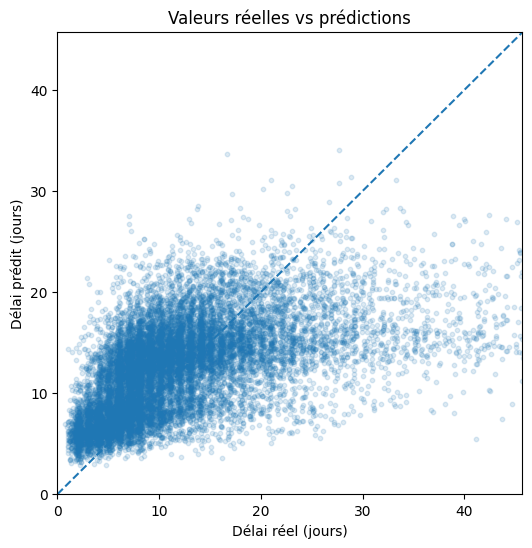

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    results["delivery_time_days"],
    results["prediction"],
    alpha=0.15,
    s=10
)

limit = max(
    results["delivery_time_days"].quantile(0.99),
    results["prediction"].quantile(0.99)
)

ax.plot([0, limit], [0, limit], linestyle="--")
ax.set_xlim(0, limit)
ax.set_ylim(0, limit)
ax.set_xlabel("Délai réel (jours)")
ax.set_ylabel("Délai prédit (jours)")
ax.set_title("Valeurs réelles vs prédictions")
plt.show()

### Questions

**Q30.** Que représenterait un point situé exactement sur la diagonale ?

**Q31.** Dans quelles zones le modèle semble-t-il le plus en difficulté ?

**Q32.** Les commandes exceptionnellement longues semblent-elles bien prédites ?

**Q33.** Que pourrait-on examiner dans les données pour comprendre ces erreurs ?

### ✅ Correction

**Q30.** Un point exactement situé sur la diagonale correspond à une commande pour laquelle la prédiction est égale au délai réel : l'erreur de prédiction est donc nulle.

**Q31.** Le modèle semble surtout en difficulté lorsque les délais réels deviennent élevés. Les points s'éloignent alors davantage de la diagonale, souvent avec des prédictions inférieures aux valeurs réelles.

**Q32.** Non. Les commandes exceptionnellement longues sont généralement fortement sous-estimées. Le modèle a tendance à ramener ses prédictions vers des valeurs plus courantes.

**Q33.** On pourrait examiner les caractéristiques des commandes concernées : distance vendeur-client, États concernés, catégories de produits, nombre de vendeurs, poids ou volume, période de l'année, délai promis, ainsi que d'éventuels événements logistiques. L'objectif serait de rechercher ce qui distingue les commandes très mal prédites des commandes ordinaires.


## 13. Évaluation finale sur le jeu de test

Nous avons utilisé le jeu de validation pour comparer nos choix. Une fois le modèle légitime retenu, nous pouvons effectuer **une évaluation finale** sur le jeu de test laissé de côté.

Pour exploiter toutes les données disponibles avant le test, nous réentraînons le pipeline sur `train + validation`.

In [ ]:
# À VOUS DE JOUER
# 1. Regroupez train et validation.
# 2. Réentraînez le modèle enrichi.
# 3. Prédisez sur test.
# 4. Calculez les métriques finales.

# train_validation = ...

# final_model = ...

# final_model.fit(...)

# y_test = ...
# y_pred_test = ...

# test_metrics = ...

## 14. Bilan

Nous sommes partis d'un système d'information relationnel pour arriver à une première prédiction.

Le chemin parcouru est plus important que l'appel à `fit()` :

$$
\boxed{
\text{Question métier}
\rightarrow
\text{unité statistique}
\rightarrow
X,Y
\rightarrow
\text{temps de prédiction}
\rightarrow
\text{split}
\rightarrow
\text{baseline}
\rightarrow
\text{modèle}
\rightarrow
\text{évaluation}
}
$$

### À retenir

Un modèle doit être évalué sur des données qu'il n'a pas utilisées pour apprendre. Une variable très prédictive peut être inutilisable si elle provient du futur. Enfin, une métrique n'a de sens que si l'on sait l'interpréter dans le contexte du problème.

### Pour préparer le TP2

Notre régression reste limitée. Cela soulève plusieurs questions :

- les relations sont-elles réellement linéaires ?
- ajouter des variables améliore-t-il toujours la généralisation ?
- certaines variables devraient-elles être transformées ?
- comment contrôler la complexité d'un modèle ?
- comment reconnaître le surapprentissage ?